# Does previous qualification predict performance?

In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Previous Qualification Category Meanings

**Secondary education** : Completed a standard high school or secondary school program.

**Higher education - bachelor's degree** : Completed a 3–4 year undergraduate university degree.

**Higher education - degree** : Completed a general university-level degree (similar to a bachelor's, depending on the country's system).

**Higher education - master's** : Completed a postgraduate master's degree.

**Higher education - doctorate** : Completed the highest academic degree (PhD or equivalent).

**Frequency of higher education** : Attended higher education but did not necessarily complete a degree.

**12th year of schooling - not completed** : Started but did not finish the final year of secondary school.

**11th year of schooling - not completed** : Started but did not finish the 11th year of secondary school.

**Other - 11th year of schooling** : Completed the 11th year through an alternative or non-standard pathway.

**10th year of schooling** : Completed up to the 10th year of schooling.

**10th year of schooling - not completed** : Started but did not finish the 10th year of schooling.

**Basic education 3rd cycle (9th/10th/11th year) or equivalent** : Completed the upper cycle of basic/compulsory education.

**Basic education 2nd cycle (6th/7th/8th year) or equivalent** : Completed the middle cycle of basic/compulsory education.

**Technological specialization course** : Completed a vocational or technical specialization program.

**Higher education - degree (1st cycle)** : Completed the first cycle of higher education under the Bologna system (equivalent to a bachelor's).

**Professional higher technical course** : Completed a professional or technical post-secondary program, typically shorter than a full degree.

**Higher education - master (2nd cycle)** : Completed the second cycle of higher education under the Bologna system (equivalent to a master's).

In [17]:
df = pd.read_csv("../student_data_categorized.csv")

In [18]:
df_prev = df.drop(columns=["Marital status", "Application mode", "Daytime/evening attendance", "Nationality"])
df_prev.head()

,Application order,Course,Previous qualification,Previous qualification (grade),Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,...,2nd_sem_credited,2nd_sem_enrolled,2nd_sem_evaluations,2nd_sem_approved,2nd_sem_grade,2nd_sem_without_eval,Unemployment rate,Inflation rate,GDP,Target
0,5,Animation and Multimedia Design,Secondary education,122.0,Basic Education 3rd Cycle (9th/10th/11th Year)...,Other - 11th Year of Schooling,"Personal Services, Security and Safety Workers...",Unskilled Workers,127.3,1,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,Tourism,Secondary education,160.0,Secondary Education - 12th Year of Schooling o...,Higher Education - Degree,Intermediate Level Technicians and Professions,Intermediate Level Technicians and Professions,142.5,1,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,5,Communication Design,Secondary education,122.0,Basic education 1st cycle (4th/5th year) or eq...,Basic education 1st cycle (4th/5th year) or eq...,Unskilled Workers,Unskilled Workers,124.8,1,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,2,Journalism and Communication,Secondary education,122.0,Basic Education 2nd Cycle (6th/7th/8th Year) o...,Basic education 1st cycle (4th/5th year) or eq...,"Personal Services, Security and Safety Workers...",Intermediate Level Technicians and Professions,119.6,1,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,1,Social Service (evening attendance),Secondary education,100.0,Basic education 1st cycle (4th/5th year) or eq...,Basic Education 2nd Cycle (6th/7th/8th Year) o...,Unskilled Workers,Unskilled Workers,141.5,0,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


C:\Users\attic\AppData\Local\Temp\ipykernel_2300\306624252.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)


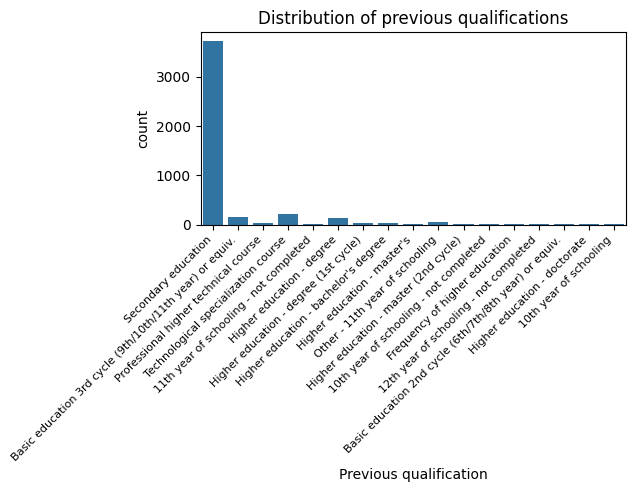

In [19]:
ax = sns.countplot(x='Previous qualification', data=df_prev)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.title("Distribution of previous qualifications")
plt.show()

# Looks like the majority of students had mostly secondary education

In [20]:
df_prev_filtered = df_prev[(df_prev['1st_sem_grade'] != 0) | (df_prev['2nd_sem_grade'] != 0)]

df_prev_filtered["grade_diff"] = df_prev_filtered["2nd_sem_grade"] - df_prev_filtered["1st_sem_grade"]
# df_prev_filtered["grade_diff_enrolled"] = df_prev_filtered["2nd_sem_approved"] - df_prev_filtered["1st_sem_approved"]

df_prev_filtered["%_credits_completed_1st_sem"] = np.where(
    df_prev_filtered["1st_sem_enrolled"] != 0,
    df_prev_filtered["1st_sem_credited"] / df_prev_filtered["1st_sem_enrolled"],
    0
)

df_prev_filtered["%_credits_completed_2nd_sem"] = np.where(
    df_prev_filtered["2nd_sem_enrolled"] != 0,
    df_prev_filtered["2nd_sem_credited"] / df_prev_filtered["2nd_sem_enrolled"],
    0
)

df_prev_filtered["%_credits_completed_diff"] = df_prev_filtered["%_credits_completed_2nd_sem"] - df_prev_filtered["%_credits_completed_1st_sem"]
df_prev_filtered.head()

,Application order,Course,Previous qualification,Previous qualification (grade),Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,...,2nd_sem_grade,2nd_sem_without_eval,Unemployment rate,Inflation rate,GDP,Target,grade_diff,%_credits_completed_1st_sem,%_credits_completed_2nd_sem,%_credits_completed_diff
1,1,Tourism,Secondary education,160.0,Secondary Education - 12th Year of Schooling o...,Higher Education - Degree,Intermediate Level Technicians and Professions,Intermediate Level Technicians and Professions,142.5,1,...,13.666667,0,13.9,-0.3,0.79,Graduate,-0.333333,0.0,0.0,0.0
3,2,Journalism and Communication,Secondary education,122.0,Basic Education 2nd Cycle (6th/7th/8th Year) o...,Basic education 1st cycle (4th/5th year) or eq...,"Personal Services, Security and Safety Workers...",Intermediate Level Technicians and Professions,119.6,1,...,12.400000,0,9.4,-0.8,-3.12,Graduate,-1.028571,0.0,0.0,0.0
4,1,Social Service (evening attendance),Secondary education,100.0,Basic education 1st cycle (4th/5th year) or eq...,Basic Education 2nd Cycle (6th/7th/8th Year) o...,Unskilled Workers,Unskilled Workers,141.5,0,...,13.000000,0,13.9,-0.3,0.79,Graduate,0.666667,0.0,0.0,0.0
5,1,Management (evening attendance),Basic education 3rd cycle (9th/10th/11th year)...,133.1,Basic education 1st cycle (4th/5th year) or eq...,Basic education 1st cycle (4th/5th year) or eq...,Unskilled Workers,"Skilled Workers in Industry, Construction and ...",114.8,0,...,11.500000,5,16.2,0.3,-0.92,Graduate,-0.357143,0.0,0.0,0.0
6,1,Nursing,Secondary education,142.0,Basic Education 3rd Cycle (9th/10th/11th Year)...,Basic Education 2nd Cycle (6th/7th/8th Year) o...,"Skilled Workers in Industry, Construction and ...",Armed Forces Professions,128.4,1,...,14.345000,0,15.5,2.8,-4.06,Graduate,1.045000,0.0,0.0,0.0


In [21]:
df_prev_filtered.groupby('Previous qualification').size()

Previous qualification
10th year of schooling                                         1
10th year of schooling - not completed                         1
11th year of schooling - not completed                         2
12th year of schooling - not completed                         2
Basic education 2nd cycle (6th/7th/8th year) or equiv.         4
Basic education 3rd cycle (9th/10th/11th year) or equiv.     114
Frequency of higher education                                 14
Higher education - bachelor's degree                          16
Higher education - degree                                     89
Higher education - degree (1st cycle)                         35
Higher education - master (2nd cycle)                          5
Higher education - master's                                    8
Other - 11th year of schooling                                25
Professional higher technical course                          35
Secondary education                                         3201
Te

In [22]:
df_prev_filtered.groupby('Previous qualification').size()

Previous qualification
10th year of schooling                                         1
10th year of schooling - not completed                         1
11th year of schooling - not completed                         2
12th year of schooling - not completed                         2
Basic education 2nd cycle (6th/7th/8th year) or equiv.         4
Basic education 3rd cycle (9th/10th/11th year) or equiv.     114
Frequency of higher education                                 14
Higher education - bachelor's degree                          16
Higher education - degree                                     89
Higher education - degree (1st cycle)                         35
Higher education - master (2nd cycle)                          5
Higher education - master's                                    8
Other - 11th year of schooling                                25
Professional higher technical course                          35
Secondary education                                         3201
Te

C:\Users\attic\AppData\Local\Temp\ipykernel_2300\3968618360.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)


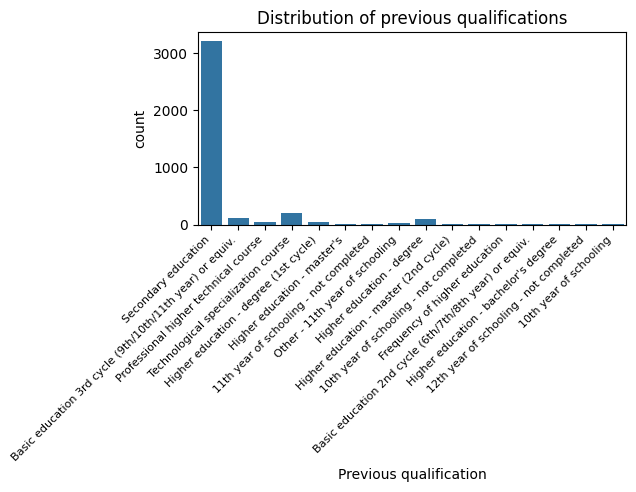

In [23]:
ax = sns.countplot(x='Previous qualification', data=df_prev_filtered)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.title("Distribution of previous qualifications")
plt.show()

# still a majority of students are high school graduates

In [24]:
# verify contain nonzero values
df_prev_filtered["%_credits_completed_1st_sem"].unique()

array([0.        , 0.33333333, 0.5       , 0.28571429, 0.25      ,
       0.7       , 0.72222222, 0.4       , 0.16666667, 0.55555556,
       0.125     , 0.9047619 , 0.64705882, 0.6       , 0.66666667,
       0.77777778, 0.2       , 0.3       , 0.625     , 0.63636364,
       0.45454545, 0.54545455, 0.71428571, 0.69230769, 0.57142857,
       0.9375    , 0.64285714, 0.58333333, 0.875     , 0.70588235,
       0.81818182, 1.        , 0.94736842, 0.94444444, 0.14285714,
       0.44444444, 0.88888889, 0.75      , 0.42857143, 0.73333333,
       0.8       , 0.61111111, 0.375     , 0.36363636, 0.92307692,
       0.78571429, 0.85714286, 0.94117647, 0.88235294, 0.6875    ,
       0.41666667, 0.76470588, 0.5625    , 0.93333333, 0.58823529,
       0.76923077, 0.72727273, 0.61538462, 0.7826087 , 0.9       ,
       0.82352941, 0.46153846, 0.73684211, 0.86666667, 0.53846154,
       0.95238095, 0.83333333, 0.22222222])

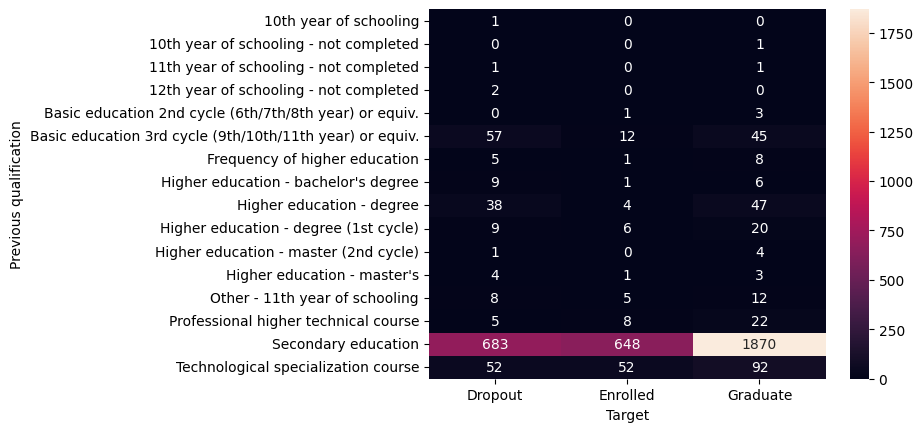

In [25]:
ct = pd.crosstab(df_prev_filtered['Previous qualification'], df_prev_filtered['Target'])

sns.heatmap(ct, annot=True, fmt='d')
plt.xlabel('Target')
plt.ylabel('Previous qualification')
plt.show()

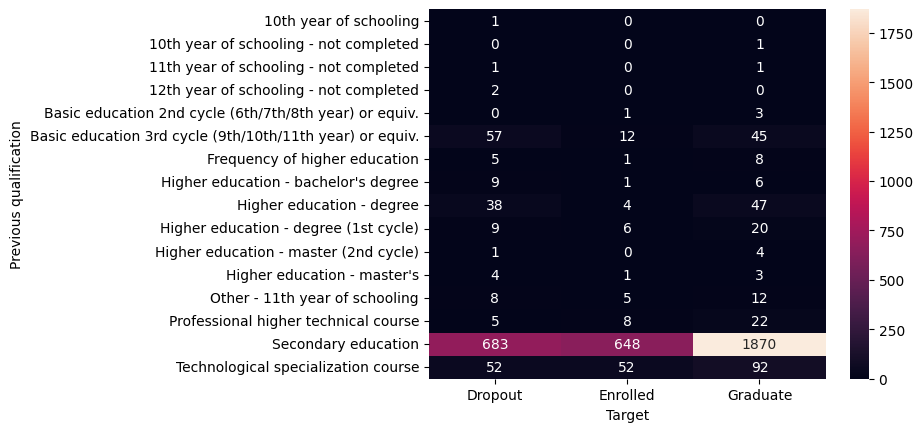

In [26]:
# don't filter out the zero grade rows
ct2 = pd.crosstab(df_prev['Previous qualification'], df_prev['Target'])

sns.heatmap(ct, annot=True, fmt='d')
plt.xlabel('Target')
plt.ylabel('Previous qualification')
plt.show()

Roughly the same picture. The previous qualification itself doesn't seem to have much correlation, but a student who graduated high school would be more likely to graduate than dropout.

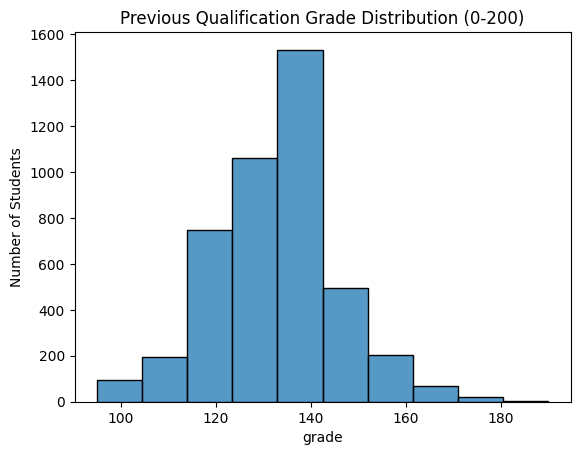

In [27]:
# Plotting Grade Distribution
sns.histplot(df_prev['Previous qualification (grade)'], bins=10)
plt.xlabel("grade")
plt.ylabel("Number of Students")
plt.title("Previous Qualification Grade Distribution (0-200)")
plt.show()

In [28]:
df_prev_filtered.groupby('Target')['grade_diff'].describe()

df_copy = df_prev_filtered

df_copy.groupby('Target')['grade_diff'].describe()

,count,mean,std,min,25%,50%,75%,max
Target,,,,,,,,
Dropout,875.0,-2.204282,5.455699,-16.142857,-1.833333,-0.45,0.500000,14.50
Enrolled,739.0,-0.008480,2.635211,-13.250000,-0.833333,0.00,0.666667,16.00
Graduate,2134.0,0.055506,1.038295,-5.000000,-0.500000,0.00,0.642857,13.75


In [29]:
df_prev_filtered.groupby('Target')['Previous qualification (grade)'].describe()

df_copy = df_prev_filtered

df_copy.groupby('Target')['Previous qualification (grade)'].describe()

,count,mean,std,min,25%,50%,75%,max
Target,,,,,,,,
Dropout,875.0,130.876571,12.740942,95.0,121.00,132.0,137.5,190.0
Enrolled,739.0,131.024493,12.837137,96.0,123.00,130.0,138.0,190.0
Graduate,2134.0,133.814199,13.232207,97.0,125.25,133.1,141.0,184.4


C:\Users\attic\AppData\Local\Temp\ipykernel_2300\1751115665.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y='Previous qualification (grade)', data=df_prev_filtered, ax=axes[0],
C:\Users\attic\AppData\Local\Temp\ipykernel_2300\1751115665.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y='grade_diff', data=df_prev_filtered, ax=axes[1],


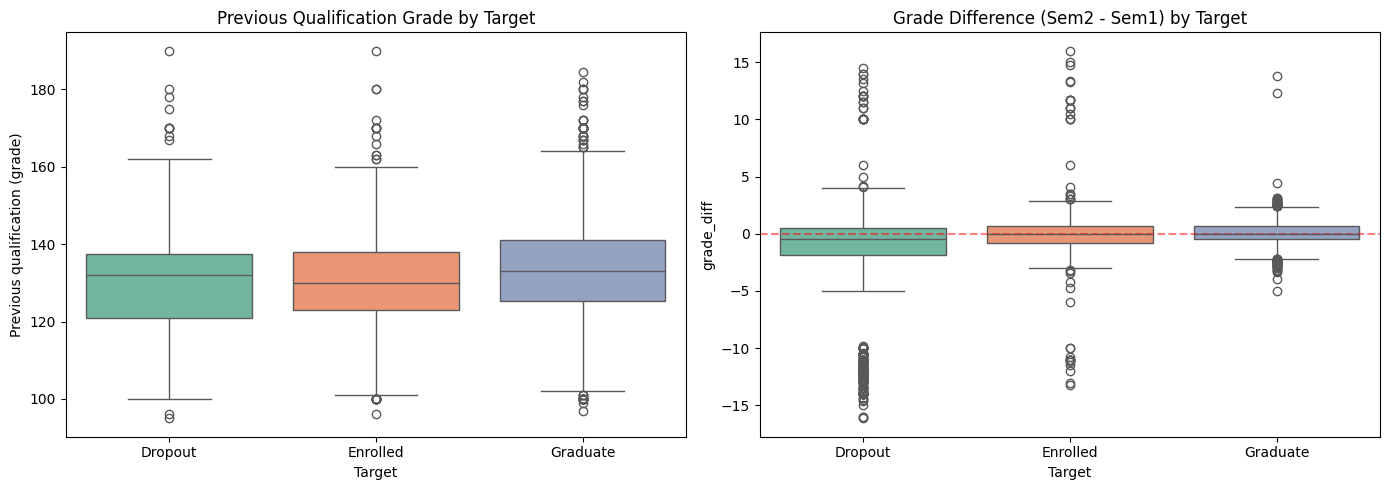

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='Target', y='Previous qualification (grade)', data=df_prev_filtered, ax=axes[0],
            order=['Dropout', 'Enrolled', 'Graduate'], palette='Set2')
axes[0].set_title('Previous Qualification Grade by Target')

sns.boxplot(x='Target', y='grade_diff', data=df_prev_filtered, ax=axes[1],
            order=['Dropout', 'Enrolled', 'Graduate'], palette='Set2')
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Grade Difference (Sem2 - Sem1) by Target')

plt.tight_layout()
plt.show()

## Results

Looking at the box plots, it seems to show that the grades of a student's previous qualifications do not affect their academic performance in college. The three box plots are nearly indisguishable, aside from a tiny difference from the Graduate targers. 

Because of this, it's safe to say that previous qualification grades don't have a large effect on a student's academic performance in the future. It's not a very good predictor for academic performance.

However for grade differences between 1st and 2nd semester, the "Graduate" box plot is more distinguishable than the dropout plot, as it has a greater median and centers more around a consistent grade difference. The median for the dropout group is negative, with many outliers sitting well in the negatives. 
For the enrolled group, it's the difference is more stable.
For the graduate group, median is essentially 0, with an extremely tight IQR clustered right at zero. This means that the majority of grade differences for the graduate group have no change. In addition, there are also outliers on both sides.

## What this means

Grade differences between 1st and 2nd semester are fairly strong predictors for academic performance. 
- If a student has a worse performance between 1st and 2nd semester, they tend to be more likely to drop out. 
- If a student has consistent performance or improves between semesters, they tend to be graduates.
- If a student is in the middle, they would tend to be in the target Enrolled.

## Notes
Even though we stated that a graduate would have better academic performance, there were outliers in the negatives, similar to the dropout group. This implies grade differences shouldn't be the sole predictor of academic performance, and that there should be other factors to consider before making a final prediction.